## Notebook for calculating lifetimes & average hydrogen bond lengths

#### System: ACN/water/TBAClO4

**Created on 1st February, 2024; modified on 14th January, 2025**

In [1]:
import math as m
import os, sys
import numpy as np
import argparse
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import warnings
warnings.filterwarnings('ignore')
from scipy.optimize import curve_fit

import MDAnalysis as mda
# from MDAnalysis.tests.datafiles import TPR, XTC
from MDAnalysis import transformations
from MDAnalysis.analysis.rdf import InterRDF
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

from dask.distributed import Client
import dask.dataframe as dd
from dask.diagnostics import ProgressBar

In [3]:
# os.chdir('/project/dfreedman/riteshk/COR-MD-hannah/CMD_Rev/')

In [2]:
%%bash
pwd
ls -ltr

/project2/chibueze/riteshk/COR-MD-hannah/CMD_Rev/acf-data_frame100_dt10
total 3458
-rw-rw-r--  1 riteshk riteshk  86650 Jan 18 11:04 acf_fit_thf-water_l1.csv
-rw-rw-r--  1 riteshk riteshk  86728 Jan 18 11:04 acf_fit_thf-water_l2.csv
-rw-rw-r--  1 riteshk riteshk  86745 Jan 18 11:04 acf_fit_thf-water_l3.csv
-rw-rw-r--  1 riteshk riteshk  86746 Jan 18 11:04 acf_fit_thf-water_l4.csv
-rw-rw-r--  1 riteshk riteshk  86701 Jan 18 11:04 acf_fit_thf-water_l5.csv
-rw-rw-r--  1 riteshk riteshk  86750 Jan 18 11:04 acf_fit_thf-water_l6.csv
-rw-rw-r--  1 riteshk riteshk  86829 Jan 18 11:04 acf_fit_thf-water_0_25.csv
-rw-rw-r--  1 riteshk riteshk  86758 Jan 18 11:04 acf_fit_thf-water_0_5.csv
-rw-rw-r--  1 riteshk riteshk    996 Jan 18 11:04 tau_thf-water_jacs_r3.csv
-rw-rw-r--  1 riteshk riteshk  86766 Jan 18 12:03 acf_fit_dmf-water_l1.csv
-rw-rw-r--  1 riteshk riteshk  86813 Jan 18 12:03 acf_fit_dmf-water_l2.csv
-rw-rw-r--  1 riteshk riteshk  86865 Jan 18 12:03 acf_fit_dmf-water_l3.csv
-rw-rw-r--  1

In [3]:
client = Client(n_workers=32, threads_per_worker=2)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42073/status,
Dashboard: http://127.0.0.1:42073/status,Workers: 32
Total threads: 64,Total memory: 54.69 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40905,Workers: 32
Dashboard: http://127.0.0.1:42073/status,Total threads: 64
Started: Just now,Total memory: 54.69 GiB
Comm: tcp://127.0.0.1:35097,Total threads: 2
Dashboard: http://127.0.0.1:35401/status,Memory: 1.71 GiB
Nanny: tcp://127.0.0.1:37263,


**water mole fractions: l1, l2, l3, l4, l5, l6, 0.25, 0.50**

### Calculations using tau_frame = 100 and dt = 1: not using

In [4]:
class HydrogenBondCalculator:
    df = pd.DataFrame(); df_1 = pd.DataFrame()
    def __init__(self, universe, solv_resname, solv_atom):
        self.u = universe
        self.solv_resname = solv_resname
        self.solv_atom = solv_atom
        self.hbonds_0 = None
        self.hbonds_1 = None

    def fit_biexponential(self, tau_timeseries, ac_timeseries):
        """Fit a biexponential function to the ACF."""
        def model(t, A, tau1, B, tau2):
            return A * np.exp(-t / tau1) + B * np.exp(-t / tau2)

        params, params_covariance = curve_fit(model, tau_timeseries, ac_timeseries, [1, 1, 1, 2], maxfev=100000)

        fit_t = np.linspace(tau_timeseries[0], tau_timeseries[-1], 1000)
        fit_ac = model(fit_t, *params)

        return params, fit_t, fit_ac

#     def autocorrelation_function(self, hbond_time_series):
#         """Calculate the autocorrelation function of a hydrogen bond presence time series."""
#         n = len(hbond_time_series)
#         acf = np.correlate(hbond_time_series, hbond_time_series, mode='full')[n-1:] / np.arange(n, 0, -1)
#         return acf / acf[0]  # Normalize by C(0)

    def calculate(self):
        self.hbonds_0 = HBA(self.u, 
                            donors_sel=f"resname wat and name O*", 
                            hydrogens_sel=f"resname wat and name H*", 
                            acceptors_sel=f"resname {self.solv_resname} and name {self.solv_atom}",
                            between=["resname wat", f"resname {self.solv_resname}"])
        self.hbonds_0.run()

#         tau_max = 25
        tau_max = 100
        window_step = 1

        tau_frames_0, hbond_lifetime_0 = self.hbonds_0.lifetime(tau_max=tau_max, window_step=window_step)

        # Compute and fit ACF
#         acf_0 = self.autocorrelation_function(hbond_lifetime_0)
        acf_0 = hbond_lifetime_0
        params_0, fit_t_0, fit_ac_0 = self.fit_biexponential(np.arange(len(acf_0)), acf_0)

        A, tau1_0, B, tau2_0 = params_0
        time_constant_0 = A * tau1_0 + B * tau2_0
        
        print(f"water-solvent H-bond lifetimes: τ1 = {tau1_0:.2f} ps, τ2 = {tau2_0:.2f} ps")

        self.hbonds_1 = HBA(self.u, 
                            donors_sel="resname wat and name O*", 
                            hydrogens_sel="resname wat and name H*", 
                            acceptors_sel="resname wat and name O*",
                            between=["resname wat", "resname wat"])
        self.hbonds_1.run()

        tau_frames_1, hbond_lifetime_1 = self.hbonds_1.lifetime(tau_max=tau_max, window_step=window_step)

#         acf_1 = self.autocorrelation_function(hbond_lifetime_1)
        acf_1 = hbond_lifetime_1
        params_1, fit_t_1, fit_ac_1 = self.fit_biexponential(np.arange(len(acf_1)), acf_1)

        A, tau1_1, B, tau2_1 = params_1
        time_constant_1 = A * tau1_1 + B * tau2_1
        
        print(f"water-water H-bond lifetimes: τ1 = {tau1_1:.2f} ps, τ2 = {tau2_1:.2f} ps")
        self.df['acf_ws'] = acf_0
        self.df['acf_ww'] = acf_1

        df_1_data = {
            'lifetime_ws': [time_constant_0],
            'tau_1_ws': [tau1_0],
            'tau_2_ws': [tau2_0],
            'lifetime_ww': [time_constant_1],
            'tau_1_ww': [tau1_1],
            'tau_2_ww': [tau2_1]
        }
        self.df_1 = pd.DataFrame(df_1_data)

        fit_df = pd.DataFrame({
            'fit_t_ws': fit_t_0,
            'fit_acf_ws': fit_ac_0,
            'fit_t_ww': fit_t_1,
            'fit_acf_ww': fit_ac_1
        })

        self.df = pd.concat([self.df, fit_df], axis=1)

        return time_constant_0, acf_0, fit_t_0, fit_ac_0, time_constant_1, acf_1, fit_t_1, fit_ac_1, self.df, self.df_1

#### reading all MD trajectory files

In [5]:
path_0 = './TBAClO4-water_xl1-solv/ACN/'
path_1 = './TBAClO4-water_xl2-solv/ACN/'
path_2 = './TBAClO4-water_xl3-solv/ACN/'
path_3 = './TBAClO4-water_xl4-solv/ACN/'
path_4 = './TBAClO4-water_xl5-solv/ACN/'
path_5 = './TBAClO4-water_xl6-solv/ACN/'
path_6 = './TBAClO4-water_x0.25-solv/ACN/'
path_7 = './TBAClO4-water_x0.5-solv/ACN/'

In [6]:
u_0 = mda.Universe(path_0 + 'config.pdb', path_0 + 'nvt3.lammpsdump')
u_1 = mda.Universe(path_1 + 'config.pdb', path_1 + 'nvt3.lammpsdump')
u_2 = mda.Universe(path_2 + 'config.pdb', path_2 + 'nvt3.lammpsdump')
u_3 = mda.Universe(path_3 + 'config.pdb', path_3 + 'nvt3.lammpsdump')
u_4 = mda.Universe(path_4 + 'config.pdb', path_4 + 'nvt3.lammpsdump')
u_5 = mda.Universe(path_5 + 'config.pdb', path_5 + 'nvt3.lammpsdump')
u_6 = mda.Universe(path_6 + 'config.pdb', path_6 + 'nvt3.lammpsdump')
u_7 = mda.Universe(path_7 + 'config.pdb', path_7 + 'nvt3.lammpsdump')

#### ACF, $\tau$, $\tau_1$, & $\tau_2$ for $\chi_{H_{2}O}$ = l$_1$

In [7]:
calculator = HydrogenBondCalculator(u_0, 'acn', 'N*')
time_constant_0_ws, acf_0_ws, fit_t_0_ws, fit_ac_0_ws, time_constant_0_ww, acf_0_ww, fit_t_0_ww, fit_ac_0_ww, df_0_0, df_0_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 0.04 ps, τ2 = 0.26 ps
water-water H-bond lifetimes: τ1 = 0.46 ps, τ2 = 1.28 ps


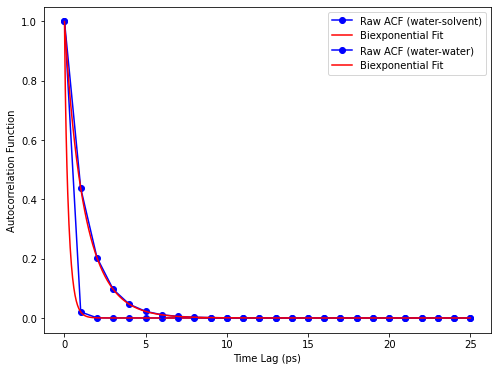

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(acf_0_ws)), acf_0_ws, 'bo-', label="Raw ACF (water-solvent)")
plt.plot(fit_t_0_ws, fit_ac_0_ws, 'r-', label="Biexponential Fit")
plt.plot(np.arange(len(acf_0_ww)), acf_0_ww, 'bo-', label="Raw ACF (water-water)")
plt.plot(fit_t_0_ww, fit_ac_0_ww, 'r-', label="Biexponential Fit")
plt.xlabel("Time Lag (ps)")
plt.ylabel("Autocorrelation Function")
# plt.title("ACF of H-bond Lifetimes for Cosolvent 1")
plt.legend()
plt.show()

In [10]:
df_0_1

,lifetime_ws,tau_1_ws,tau_2_ws,lifetime_ww,tau_1_ww,tau_2_ww
0,0.24114,0.04116,0.264376,1.254503,0.525971,1.359336


#### ACF, $\tau$, $\tau_1$, & $\tau_2$ for $\chi_{H_{2}O}$ = l$_2$

In [8]:
calculator = HydrogenBondCalculator(u_1, 'acn', 'N*')
time_constant_1_ws, acf_1_ws, fit_t_1_ws, fit_ac_1_ws, time_constant_1_ww, acf_1_ww, fit_t_1_ww, fit_ac_1_ww, df_1_0, df_1_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 0.04 ps, τ2 = 0.26 ps
water-water H-bond lifetimes: τ1 = 0.53 ps, τ2 = 1.20 ps


#### ACF, $\tau$, $\tau_1$, & $\tau_2$ for $\chi_{H_{2}O}$ = l$_3$

In [9]:
calculator = HydrogenBondCalculator(u_2, 'acn', 'N*')
time_constant_2_ws, acf_2_ws, fit_t_2_ws, fit_ac_2_ws, time_constant_2_ww, acf_2_ww, fit_t_2_ww, fit_ac_2_ww, df_2_0, df_2_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 0.18 ps, τ2 = 0.28 ps
water-water H-bond lifetimes: τ1 = 0.01 ps, τ2 = 0.93 ps


#### ACF, $\tau$, $\tau_1$, & $\tau_2$ for $\chi_{H_{2}O}$ = l$_4$

In [10]:
calculator = HydrogenBondCalculator(u_3, 'acn', 'N*')
time_constant_3_ws, acf_3_ws, fit_t_3_ws, fit_ac_3_ws, time_constant_3_ww, acf_3_ww, fit_t_3_ww, fit_ac_3_ww, df_3_0, df_3_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 0.04 ps, τ2 = 0.26 ps
water-water H-bond lifetimes: τ1 = 0.45 ps, τ2 = 1.00 ps


#### ACF, $\tau$, $\tau_1$, & $\tau_2$ for $\chi_{H_{2}O}$ = l$_5$

In [11]:
calculator = HydrogenBondCalculator(u_4, 'acn', 'N*')
time_constant_4_ws, acf_4_ws, fit_t_4_ws, fit_ac_4_ws, time_constant_4_ww, acf_4_ww, fit_t_4_ww, fit_ac_4_ww, df_4_0, df_4_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 0.04 ps, τ2 = 0.26 ps
water-water H-bond lifetimes: τ1 = 0.44 ps, τ2 = 0.92 ps


#### ACF, $\tau$, $\tau_1$, & $\tau_2$ for $\chi_{H_{2}O}$ = l$_6$

In [12]:
calculator = HydrogenBondCalculator(u_5, 'acn', 'N*')
time_constant_5_ws, acf_5_ws, fit_t_5_ws, fit_ac_5_ws, time_constant_5_ww, acf_5_ww, fit_t_5_ww, fit_ac_5_ww, df_5_0, df_5_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 0.22 ps, τ2 = 0.27 ps
water-water H-bond lifetimes: τ1 = 0.43 ps, τ2 = 0.87 ps


#### ACF, $\tau$, $\tau_1$, & $\tau_2$ for $\chi_{H_{2}O}$ = 0.25

In [13]:
calculator = HydrogenBondCalculator(u_6, 'acn', 'N*')
time_constant_6_ws, acf_6_ws, fit_t_6_ws, fit_ac_6_ws, time_constant_6_ww, acf_6_ww, fit_t_6_ww, fit_ac_6_ww, df_6_0, df_6_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 0.25 ps, τ2 = 0.34 ps
water-water H-bond lifetimes: τ1 = 0.44 ps, τ2 = 0.95 ps


#### ACF, $\tau$, $\tau_1$, & $\tau_2$ for $\chi_{H_{2}O}$ = 0.5

In [14]:
calculator = HydrogenBondCalculator(u_7, 'acn', 'N*')
time_constant_7_ws, acf_7_ws, fit_t_7_ws, fit_ac_7_ws, time_constant_7_ww, acf_7_ww, fit_t_7_ww, fit_ac_7_ww, df_7_0, df_7_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 0.23 ps, τ2 = 0.32 ps


distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)


water-water H-bond lifetimes: τ1 = 0.41 ps, τ2 = 0.80 ps


In [15]:
df_0_0.to_csv('acf-data_tau_frame_100/acf_fit_acn-water_l1.csv', index=False)
df_1_0.to_csv('acf-data_tau_frame_100/acf_fit_acn-water_l2.csv', index=False)
df_2_0.to_csv('acf-data_tau_frame_100/acf_fit_acn-water_l3.csv', index=False)
df_3_0.to_csv('acf-data_tau_frame_100/acf_fit_acn-water_l4.csv', index=False)
df_4_0.to_csv('acf-data_tau_frame_100/acf_fit_acn-water_l5.csv', index=False)
df_5_0.to_csv('acf-data_tau_frame_100/acf_fit_acn-water_l6.csv', index=False)
df_6_0.to_csv('acf-data_tau_frame_100/acf_fit_acn-water_0_25.csv', index=False)
df_7_0.to_csv('acf-data_tau_frame_100/acf_fit_acn-water_0_5.csv', index=False)

In [16]:
df_0_1['mol_frac'] = 'l1'
df_1_1['mol_frac'] = 'l2'
df_2_1['mol_frac'] = 'l3'
df_3_1['mol_frac'] = 'l4'
df_4_1['mol_frac'] = 'l5'
df_5_1['mol_frac'] = 'l6'
df_6_1['mol_frac'] = '0.25'
df_7_1['mol_frac'] = '0.5'
df_all_1 = pd.concat([df_0_1, df_1_1, df_2_1, df_3_1, df_4_1, df_5_1, df_6_1, df_7_1], axis=0)
df_all_1.to_csv('acf-data_tau_frame_100/tau_acn-water_jacs_r3.csv', index=False)

In [17]:
df_all_1

,lifetime_ws,tau_1_ws,tau_2_ws,lifetime_ww,tau_1_ww,tau_2_ww,mol_frac
0,0.239006,0.042098,0.261557,1.177019,0.461226,1.275302,l1
0,0.242472,0.042168,0.261834,0.984345,0.531913,1.195023,l2
0,0.248603,0.184550,0.278853,0.694289,0.009487,0.925040,l3
0,0.241583,0.043331,0.256525,0.657180,0.454069,0.995002,l4
0,0.239380,0.039381,0.255772,0.588516,0.436126,0.923164,l5
0,0.243944,0.220243,0.269468,0.554910,0.425352,0.871494,l6
0,0.249540,0.247034,0.336557,0.611829,0.443134,0.952793,0.25
0,0.239410,0.234010,0.321518,0.514368,0.414625,0.797043,0.5


distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)


### Calculations using tau_frame = 100 and dt = 10: using it finally

In [4]:
class HydrogenBondCalculator:
    df = pd.DataFrame(); df_1 = pd.DataFrame()
    def __init__(self, universe, solv_resname, solv_atom):
        self.u = universe
        self.solv_resname = solv_resname
        self.solv_atom = solv_atom
        self.hbonds_0 = None
        self.hbonds_1 = None

    def fit_biexponential(self, tau_timeseries, ac_timeseries):
        """Fit a biexponential function to the ACF."""
        def model(t, A, tau1, B, tau2):
            return A * np.exp(-t / tau1) + B * np.exp(-t / tau2)

        params, params_covariance = curve_fit(model, tau_timeseries, ac_timeseries, [1, 1, 1, 2], maxfev=100000)

        fit_t = np.linspace(tau_timeseries[0], tau_timeseries[-1], 1000)
        fit_ac = model(fit_t, *params)

        return params, fit_t, fit_ac

    def calculate(self):
        self.hbonds_0 = HBA(self.u, 
                            donors_sel=f"resname wat and name O*", 
                            hydrogens_sel=f"resname wat and name H*", 
                            acceptors_sel=f"resname {self.solv_resname} and name {self.solv_atom}",
                            between=["resname wat", f"resname {self.solv_resname}"])
        self.hbonds_0.run()

        tau_max = 100
        window_step = 1

        tau_frames_0, hbond_lifetime_0 = self.hbonds_0.lifetime(tau_max=tau_max, window_step=window_step)

        acf_0 = hbond_lifetime_0
        tau_times_0 = tau_frames_0 * self.u.trajectory.dt
        params_0, fit_t_0, fit_ac_0 = self.fit_biexponential(tau_times_0, acf_0)

        A, tau1_0, B, tau2_0 = params_0
        time_constant_0 = A * tau1_0 + B * tau2_0
        
        print(f"water-solvent H-bond lifetimes: τ1 = {tau1_0:.2f} ps, τ2 = {tau2_0:.2f} ps")

        self.hbonds_1 = HBA(self.u, 
                            donors_sel="resname wat and name O*", 
                            hydrogens_sel="resname wat and name H*", 
                            acceptors_sel="resname wat and name O*",
                            between=["resname wat", "resname wat"])
        self.hbonds_1.run()

        tau_frames_1, hbond_lifetime_1 = self.hbonds_1.lifetime(tau_max=tau_max, window_step=window_step)

        acf_1 = hbond_lifetime_1
        tau_times_1 = tau_frames_1 * self.u.trajectory.dt
        params_1, fit_t_1, fit_ac_1 = self.fit_biexponential(tau_times_1, acf_1)

        A, tau1_1, B, tau2_1 = params_1
        time_constant_1 = A * tau1_1 + B * tau2_1
        
        print(f"water-water H-bond lifetimes: τ1 = {tau1_1:.2f} ps, τ2 = {tau2_1:.2f} ps")
        self.df['tau_time_ws'] = tau_times_0
        self.df['acf_ws'] = acf_0
        self.df['tau_time_ww'] = tau_times_1
        self.df['acf_ww'] = acf_1

        df_1_data = {
            'lifetime_ws': [time_constant_0],
            'tau_1_ws': [tau1_0],
            'tau_2_ws': [tau2_0],
            'lifetime_ww': [time_constant_1],
            'tau_1_ww': [tau1_1],
            'tau_2_ww': [tau2_1]
        }
        self.df_1 = pd.DataFrame(df_1_data)

        fit_df = pd.DataFrame({
            'fit_t_ws': fit_t_0,
            'fit_acf_ws': fit_ac_0,
            'fit_t_ww': fit_t_1,
            'fit_acf_ww': fit_ac_1
        })

        self.df = pd.concat([self.df, fit_df], axis=1)

        return time_constant_0, acf_0, fit_t_0, fit_ac_0, time_constant_1, acf_1, fit_t_1, fit_ac_1, self.df, self.df_1

In [5]:
path_0 = '../TBAClO4-water_xl1-solv/ACN/'
path_1 = '../TBAClO4-water_xl2-solv/ACN/'
path_2 = '../TBAClO4-water_xl3-solv/ACN/'
path_3 = '../TBAClO4-water_xl4-solv/ACN/'
path_4 = '../TBAClO4-water_xl5-solv/ACN/'
path_5 = '../TBAClO4-water_xl6-solv/ACN/'
path_6 = '../TBAClO4-water_x0.25-solv/ACN/'
path_7 = '../TBAClO4-water_x0.5-solv/ACN/'

In [6]:
u_0 = mda.Universe(path_0 + 'config.pdb', path_0 + 'nvt3.lammpsdump', dt=10.0)
u_1 = mda.Universe(path_1 + 'config.pdb', path_1 + 'nvt3.lammpsdump', dt=10.0)
u_2 = mda.Universe(path_2 + 'config.pdb', path_2 + 'nvt3.lammpsdump', dt=10.0)
u_3 = mda.Universe(path_3 + 'config.pdb', path_3 + 'nvt3.lammpsdump', dt=10.0)
u_4 = mda.Universe(path_4 + 'config.pdb', path_4 + 'nvt3.lammpsdump', dt=10.0)
u_5 = mda.Universe(path_5 + 'config.pdb', path_5 + 'nvt3.lammpsdump', dt=10.0)
u_6 = mda.Universe(path_6 + 'config.pdb', path_6 + 'nvt3.lammpsdump', dt=10.0)
u_7 = mda.Universe(path_7 + 'config.pdb', path_7 + 'nvt3.lammpsdump', dt=10.0)

In [21]:
u_0.residues.resnames

array(['acn', 'acn', 'acn', ..., 'clo', 'clo', 'clo'], dtype=object)

In [7]:
calculator = HydrogenBondCalculator(u_0, 'acn', 'N*')
time_constant_0_ws, acf_0_ws, fit_t_0_ws, fit_ac_0_ws, time_constant_0_ww, acf_0_ww, fit_t_0_ww, fit_ac_0_ww, df_0_0, df_0_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 2.62 ps, τ2 = 0.40 ps
water-water H-bond lifetimes: τ1 = 12.75 ps, τ2 = 4.61 ps


In [8]:
df_0_1

,lifetime_ws,tau_1_ws,tau_2_ws,lifetime_ww,tau_1_ww,tau_2_ww
0,2.38754,2.615572,0.396423,11.770186,12.753016,4.612264


In [9]:
calculator = HydrogenBondCalculator(u_1, 'acn', 'N*')
time_constant_1_ws, acf_1_ws, fit_t_1_ws, fit_ac_1_ws, time_constant_1_ww, acf_1_ww, fit_t_1_ww, fit_ac_1_ww, df_1_0, df_1_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 0.13 ps, τ2 = 2.62 ps
water-water H-bond lifetimes: τ1 = 11.95 ps, τ2 = 5.32 ps


In [10]:
calculator = HydrogenBondCalculator(u_2, 'acn', 'N*')
time_constant_2_ws, acf_2_ws, fit_t_2_ws, fit_ac_2_ws, time_constant_2_ww, acf_2_ww, fit_t_2_ww, fit_ac_2_ww, df_2_0, df_2_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 2.56 ps, τ2 = 2.56 ps
water-water H-bond lifetimes: τ1 = 10.89 ps, τ2 = 4.78 ps


In [11]:
calculator = HydrogenBondCalculator(u_3, 'acn', 'N*')
time_constant_3_ws, acf_3_ws, fit_t_3_ws, fit_ac_3_ws, time_constant_3_ww, acf_3_ww, fit_t_3_ww, fit_ac_3_ww, df_3_0, df_3_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 2.57 ps, τ2 = 0.40 ps
water-water H-bond lifetimes: τ1 = 9.95 ps, τ2 = 4.54 ps


In [12]:
calculator = HydrogenBondCalculator(u_4, 'acn', 'N*')
time_constant_4_ws, acf_4_ws, fit_t_4_ws, fit_ac_4_ws, time_constant_4_ww, acf_4_ww, fit_t_4_ww, fit_ac_4_ww, df_4_0, df_4_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 0.44 ps, τ2 = 2.56 ps
water-water H-bond lifetimes: τ1 = 4.36 ps, τ2 = 9.23 ps


In [13]:
calculator = HydrogenBondCalculator(u_5, 'acn', 'N*')
time_constant_5_ws, acf_5_ws, fit_t_5_ws, fit_ac_5_ws, time_constant_5_ww, acf_5_ww, fit_t_5_ww, fit_ac_5_ww, df_5_0, df_5_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 2.69 ps, τ2 = 2.20 ps
water-water H-bond lifetimes: τ1 = 4.25 ps, τ2 = 8.71 ps


In [14]:
calculator = HydrogenBondCalculator(u_6, 'acn', 'N*')
time_constant_6_ws, acf_6_ws, fit_t_6_ws, fit_ac_6_ws, time_constant_6_ww, acf_6_ww, fit_t_6_ww, fit_ac_6_ww, df_6_0, df_6_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 2.47 ps, τ2 = 3.37 ps
water-water H-bond lifetimes: τ1 = 9.53 ps, τ2 = 4.43 ps


In [15]:
calculator = HydrogenBondCalculator(u_7, 'acn', 'N*')
time_constant_7_ws, acf_7_ws, fit_t_7_ws, fit_ac_7_ws, time_constant_7_ww, acf_7_ww, fit_t_7_ww, fit_ac_7_ww, df_7_0, df_7_1 = calculator.calculate()

water-solvent H-bond lifetimes: τ1 = 3.22 ps, τ2 = 2.34 ps
water-water H-bond lifetimes: τ1 = 7.97 ps, τ2 = 4.15 ps


In [16]:
# df_0_0.to_csv('acf-data_frame100_dt10/acf_fit_acn-water_l1.csv', index=False)
df_0_0.to_csv('acf_fit_acn-water_l1_n.csv', index=False)
df_1_0.to_csv('acf_fit_acn-water_l2_n.csv', index=False)
df_2_0.to_csv('acf_fit_acn-water_l3_n.csv', index=False)
df_3_0.to_csv('acf_fit_acn-water_l4_n.csv', index=False)
df_4_0.to_csv('acf_fit_acn-water_l5_n.csv', index=False)
df_5_0.to_csv('acf_fit_acn-water_l6_n.csv', index=False)
df_6_0.to_csv('acf_fit_acn-water_0_25_n.csv', index=False)
df_7_0.to_csv('acf_fit_acn-water_0_5_n.csv', index=False)

In [17]:
df_0_1['mol_frac'] = 'l1'
df_1_1['mol_frac'] = 'l2'
df_2_1['mol_frac'] = 'l3'
df_3_1['mol_frac'] = 'l4'
df_4_1['mol_frac'] = 'l5'
df_5_1['mol_frac'] = 'l6'
df_6_1['mol_frac'] = '0.25'
df_7_1['mol_frac'] = '0.5'
df_all_1 = pd.concat([df_0_1, df_1_1, df_2_1, df_3_1, df_4_1, df_5_1, df_6_1, df_7_1], axis=0)
df_all_1.to_csv('tau_acn-water_jacs_r3_n.csv', index=False)

In [18]:
df_all_1

,lifetime_ws,tau_1_ws,tau_2_ws,lifetime_ww,tau_1_ww,tau_2_ww,mol_frac
0,2.387540,2.615572,0.396423,11.770186,12.753016,4.612264,l1
0,2.398800,0.127629,2.618339,9.843453,11.950232,5.319129,l2
0,2.564210,2.564210,2.564210,7.678802,10.894163,4.776279,l3
0,2.413352,2.565255,0.397937,6.571802,9.950020,4.540690,l4
0,2.397652,0.444682,2.557718,5.885155,4.361256,9.231637,l5
0,2.439444,2.694684,2.202427,5.549099,4.253520,8.714937,l6
0,2.495402,2.470344,3.365572,6.118295,9.527934,4.431336,0.25
0,2.394099,3.215183,2.340105,5.143676,7.970427,4.146252,0.5


#### old calculations (for reference)

In [13]:
# calculator = HydrogenBondCalculator(u_0, 'acn', 'N*')
# time_constant_0_ws, num_0_ws, time_constant_0_ww, num_0_ww = calculator.calculate()
# print(f"time_constant for l1 mole fraction = {time_constant_0_ws:.2f} ps")
# print("Average # of H-bonds b/w water-solv for l1 mole fraction:", num_0_ws)
# print(f"time_constant for l1 mole fraction = {time_constant_0_ww:.2f} ps")
# print("Average # of H-bonds b/w water-water for l1 mole fraction:", num_0_ww)

time_constant for l1 mole fraction = 0.24 ps
Average # of H-bonds b/w water-solv for l1 mole fraction: 0.4789611744635378
time_constant for l1 mole fraction = 1.18 ps
Average # of H-bonds b/w water-water for l1 mole fraction: 0.933691360439898


In [16]:
# calculator = HydrogenBondCalculator(u_1, 'acn', 'N*')
# time_constant_1_ws, num_1_ws, time_constant_1_ww, num_1_ww = calculator.calculate()
# print(f"time_constant for l2 mole fraction = {time_constant_1_ws:.2f} ps")
# print("Average # of H-bonds b/w water-solv for l2 mole fraction:", num_1_ws)
# print(f"time_constant for l2 mole fraction = {time_constant_1_ww:.2f} ps")
# print("Average # of H-bonds b/w water-water for l2 mole fraction:", num_1_ww)

time_constant for l2 mole fraction = 0.24 ps
Average # of H-bonds b/w water-solv for l2 mole fraction: 0.3725835346058823
time_constant for l2 mole fraction = 0.98 ps
Average # of H-bonds b/w water-water for l2 mole fraction: 1.32746008213228


In [17]:
# calculator = HydrogenBondCalculator(u_2, 'acn', 'N*')
# time_constant_2_ws, num_2_ws, time_constant_2_ww, num_2_ww = calculator.calculate()
# print(f"time_constant for l3 mole fraction = {time_constant_2_ws:.2f} ps")
# print("Average # of H-bonds b/w water-solv for l3 mole fraction:", num_2_ws)
# print(f"time_constant for l3 mole fraction = {time_constant_2_ww:.2f} ps")
# print("Average # of H-bonds b/w water-water for l3 mole fraction:", num_2_ww)

time_constant for l3 mole fraction = 0.25 ps
Average # of H-bonds b/w water-solv for l3 mole fraction: 0.25733984454586567
time_constant for l3 mole fraction = 0.77 ps
Average # of H-bonds b/w water-water for l3 mole fraction: 1.6795620194413505


In [18]:
# calculator = HydrogenBondCalculator(u_3, 'acn', 'N*')
# time_constant_3_ws, num_3_ws, time_constant_3_ww, num_3_ww = calculator.calculate()
# print(f"time_constant for 0.25 mole fraction = {time_constant_3_ws:.2f} ps")
# print("Average # of H-bonds b/w water-solv for l4 mole fraction:", num_3_ws)
# print(f"time_constant for 0.25 mole fraction = {time_constant_3_ww:.2f} ps")
# print("Average # of H-bonds b/w water-water for l4 mole fraction:", num_3_ww)

time_constant for 0.25 mole fraction = 0.24 ps
Average # of H-bonds b/w water-solv for l4 mole fraction: 0.1835782496838617
time_constant for 0.25 mole fraction = 0.66 ps
Average # of H-bonds b/w water-water for l4 mole fraction: 1.9215087515373033


In [19]:
# calculator = HydrogenBondCalculator(u_4, 'acn', 'N*')
# time_constant_4_ws, num_4_ws, time_constant_4_ww, num_4_ww = calculator.calculate()
# print(f"time_constant for 0.5 mole fraction = {time_constant_4_ws:.2f} ps")
# print("Average # of H-bonds b/w water-solv for l5 mole fraction:", num_4_ws)
# print(f"time_constant for 0.5 mole fraction = {time_constant_4_ww:.2f} ps")
# print("Average # of H-bonds b/w water-water for l5 mole fraction:", num_4_ww)

time_constant for 0.5 mole fraction = 0.24 ps
Average # of H-bonds b/w water-solv for l5 mole fraction: 0.1392005812730216
time_constant for 0.5 mole fraction = 0.59 ps
Average # of H-bonds b/w water-water for l5 mole fraction: 2.0742551036725123


In [10]:
# calculator = HydrogenBondCalculator(u_5, 'acn', 'N*')
# time_constant_5_ws, num_5_ws, time_constant_5_ww, num_5_ww = calculator.calculate()
# print(f"time_constant for l6 mole fraction = {time_constant_5_ws:.2f} ps")
# print("Average # of H-bonds b/w water-solv for l6 mole fraction:", num_5_ws)
# print(f"time_constant for l6 mole fraction = {time_constant_5_ww:.2f} ps")
# print("Average # of H-bonds b/w water-water for l6 mole fraction:", num_5_ww)

/scratch/midway3/riteshk/anaconda3/lib/python3.9/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:672: DeprecationWarning: The `hbonds` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.hbonds` instead.
  warnings.warn(wmsg, DeprecationWarning)


time_constant for l6 mole fraction = 0.24 ps
Average # of H-bonds b/w water-solv for l6 mole fraction: 0.11647742333581022
time_constant for l6 mole fraction = 0.55 ps
Average # of H-bonds b/w water-water for l6 mole fraction: 2.1514904813429108


In [14]:
# calculator = HydrogenBondCalculator(u_6, 'acn', 'N*')
# time_constant_6_ws, num_6_ws, time_constant_6_ww, num_6_ww = calculator.calculate()
# print(f"time_constant for 0.25 mole fraction = {time_constant_6_ws:.2f} ps")
# print("Average # of H-bonds b/w water-solv for 0.25 mole fraction:", num_6_ws)
# print(f"time_constant for 0.25 mole fraction = {time_constant_6_ww:.2f} ps")
# print("Average # of H-bonds b/w water-water for 0.25 mole fraction:", num_6_ww)

time_constant for 0.25 mole fraction = 0.25 ps
Average # of H-bonds b/w water-solv for 0.25 mole fraction: 0.15405838920834083
time_constant for 0.25 mole fraction = 0.61 ps
Average # of H-bonds b/w water-water for 0.25 mole fraction: 2.018483187241652


In [15]:
# calculator = HydrogenBondCalculator(u_7, 'acn', 'N*')
# time_constant_7_ws, num_7_ws, time_constant_7_ww, num_7_ww = calculator.calculate()
# print(f"time_constant for 0.5 mole fraction = {time_constant_7_ws:.2f} ps")
# print("Average # of H-bonds b/w water-solv for 0.5 mole fraction:", num_7_ws)
# print(f"time_constant for 0.5 mole fraction = {time_constant_7_ww:.2f} ps")
# print("Average # of H-bonds b/w water-water for 0.5 mole fraction:", num_7_ww)

distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)
distributed.utils_perf - WARNING - full garbage collections took 10% CPU time recently (threshold: 10%)


time_constant for 0.5 mole fraction = 0.24 ps
Average # of H-bonds b/w water-solv for 0.5 mole fraction: 0.0885584774833146
time_constant for 0.5 mole fraction = 0.51 ps
Average # of H-bonds b/w water-water for 0.5 mole fraction: 2.251237162584605


In [22]:
mol_frac_wat = ['l1', 'l2', 'l3', 'l4', 'l5', 'l6', 0.25, 0.50]
time_const_ws_arr = [time_constant_0_ws, time_constant_1_ws, time_constant_2_ws, time_constant_3_ws, time_constant_4_ws, time_constant_5_ws, time_constant_6_ws, time_constant_7_ws]
time_const_ww_arr = [time_constant_0_ww, time_constant_1_ww, time_constant_2_ww, time_constant_3_ww, time_constant_4_ww, time_constant_5_ww, time_constant_6_ww, time_constant_7_ww]
num_ws_arr = [num_0_ws, num_1_ws, num_2_ws, num_3_ws, num_4_ws, num_5_ws, num_6_ws, num_7_ws]
num_ww_arr = [num_0_ww, num_1_ww, num_2_ww, num_3_ww, num_4_ww, num_5_ww, num_6_ww, num_7_ww]
dict_fin = {'water_mol_frac': mol_frac_wat, 'lifetime_water-solv': time_const_ws_arr, 'lifetime_water-water': time_const_ww_arr, 'avg_num_hb_water-solv': num_ws_arr, 'avg_num_hb_water-water': num_ww_arr}
df_fin = pd.DataFrame(dict_fin)
df_fin

,water_mol_frac,lifetime_water-solv,lifetime_water-water,avg_num_hb_water-solv,avg_num_hb_water-water
0,l1,0.238746,1.177019,0.478961,0.933691
1,l2,0.242503,0.984345,0.372584,1.327460
2,l3,0.248603,0.767880,0.257340,1.679562
3,l4,0.241526,0.657180,0.183578,1.921509
4,l5,0.239456,0.588516,0.139201,2.074255
5,l6,0.243944,0.554910,0.116477,2.151490
6,0.25,0.249540,0.611829,0.154058,2.018483
7,0.5,0.239410,0.514368,0.088558,2.251237


In [23]:
df_fin.to_csv('data_lifetime_num_hb_acn.csv', index=False)